# Timestamp cadence EDA (row-to-row gaps)

Loads a CSV under `data/`, sorts by time, then for **row 2 onward** computes **Δt = TIMESTAMP[i] − TIMESTAMP[i−1]** in seconds (and minutes). Row 1 has no previous row, so its gap is NaN.

**Why the timeline looked flat at “0”:** a handful of gaps can be **days long**. On a linear **seconds** axis, ~300 s is invisible next to 40 M s. Plots below use **minutes** and a **capped y-range** on the timeline so the usual ~5 min cadence is visible; huge gaps are still summarized in the table and histogram (clipped range).

**Timeline:** x = **TIMESTAMP[i]**, y = **Δt in minutes** (capped — adjust `TIMELINE_YMAX_MINUTES`). Matplotlib is static; the next code cell is an **interactive Plotly** version (zoom, pan, range slider, hover shows uncapped Δt). It **writes HTML** next to the CSV and **opens it in your default browser** (no inline notebook renderer, so no `nbformat` requirement). Requires `pip install plotly`.

In [56]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Edit these ---
CSV_PATH = Path("data/AHU_2_9_motor_NDE_H.csv")
TIMESTAMP_COLUMN = "TIMESTAMP"

# Nominal step (e.g. 5 min = 300 s)
NOMINAL_STEP_SEC = 300.0
NOMINAL_STEP_MIN = NOMINAL_STEP_SEC / 60.0

# Histogram: clip x-axis at this many *minutes* (longer gaps omitted from bars only)
HIST_XMAX_MIN = 90.0

# Timeline y-axis: show 0 … this many minutes (points above are clipped from view only)
TIMELINE_YMAX_MINUTES = 45.0

# If timestamps look like DD/MM/YYYY, set True
DAYFIRST = True

assert CSV_PATH.is_file(), f"Not found: {CSV_PATH.resolve()}"

In [57]:
df = pd.read_csv(CSV_PATH)
if TIMESTAMP_COLUMN not in df.columns:
    raise ValueError(f"Missing {TIMESTAMP_COLUMN!r}. Columns: {list(df.columns)}")

df = df.copy()
df[TIMESTAMP_COLUMN] = pd.to_datetime(
    df[TIMESTAMP_COLUMN], errors="coerce", utc=False, dayfirst=DAYFIRST
)
n_bad_ts = int(df[TIMESTAMP_COLUMN].isna().sum())
if n_bad_ts:
    print(f"Warning: {n_bad_ts} rows could not be parsed as timestamps (dropped for diff).")

df = df.dropna(subset=[TIMESTAMP_COLUMN]).sort_values(TIMESTAMP_COLUMN).reset_index(drop=True)

# Consecutive differences: first row NaN (no prior), second row = row2 - row1, etc.
dt_sec = df[TIMESTAMP_COLUMN].diff().dt.total_seconds()
df["delta_seconds"] = dt_sec
df["delta_minutes"] = dt_sec / 60.0

valid = df["delta_seconds"].dropna()
valid_min = df["delta_minutes"].dropna()
print(f"File: {CSV_PATH}")
print(f"Rows after sort & valid timestamps: {len(df)}")
print(f"Gap samples (row 2 onward): {len(valid)}")

File: data\AHU_2_9_motor_NDE_H.csv
Rows after sort & valid timestamps: 73402
Gap samples (row 2 onward): 73401


In [58]:
if len(valid) == 0:
    raise ValueError("No consecutive gaps to summarize (need at least 2 rows).")

qs = [0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]
qvals = valid.quantile(qs)
summary = pd.DataFrame(
    {"quantile": qs, "delta_seconds": qvals.values, "delta_minutes": (qvals.values / 60.0)}
)
display(summary)

near_nom = (valid - NOMINAL_STEP_SEC).abs() <= 30  # ±30 s around 5 min
print(
    f"Within {NOMINAL_STEP_SEC}s ± 30s: {near_nom.sum()} / {len(valid)} "
    f"({100.0 * near_nom.mean():.2f}%)"
)
print(f"Exact zero gaps (duplicate or same timestamp): {(valid == 0).sum()}")
print(f"Negative gaps (time went backwards — check data): {(valid < 0).sum()}")

,quantile,delta_seconds,delta_minutes
0,0.00,0.0,0.0
1,0.01,300.0,5.0
2,0.05,300.0,5.0
3,0.25,300.0,5.0
4,0.50,300.0,5.0
5,0.75,300.0,5.0
6,0.95,600.0,10.0
7,0.99,1500.0,25.0
8,1.00,23611200.0,393520.0


Within 300.0s ± 30s: 63991 / 73401 (87.18%)
Exact zero gaps (duplicate or same timestamp): 58
Negative gaps (time went backwards — check data): 0


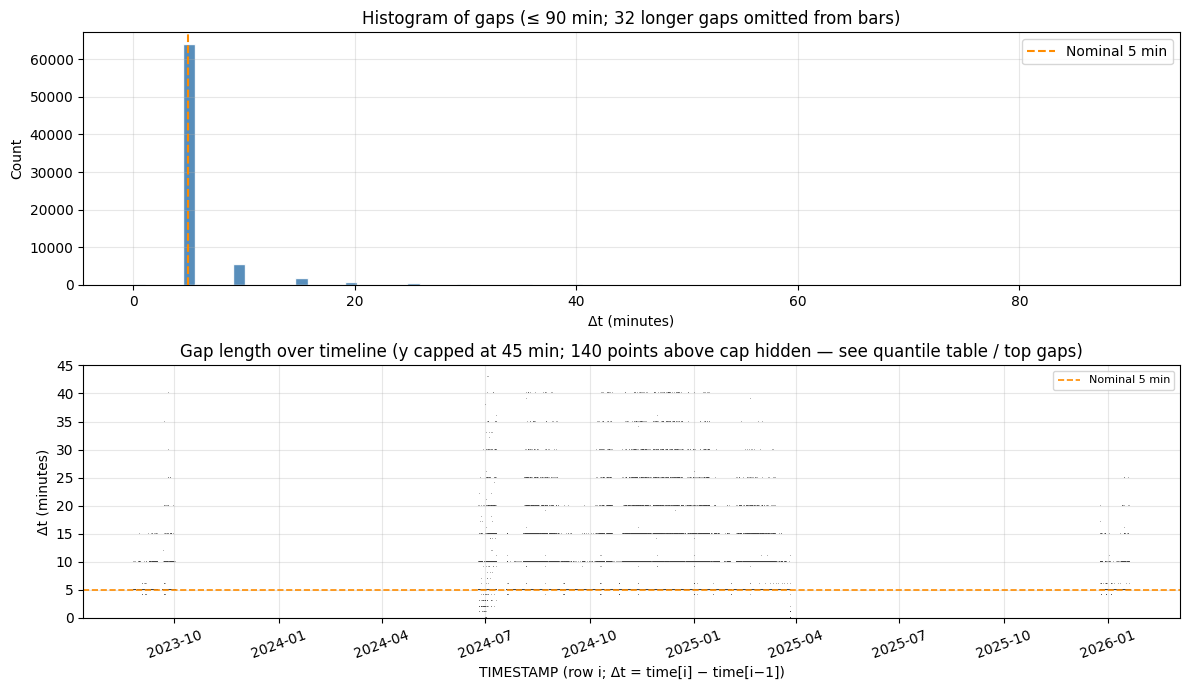

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

ax0 = axes[0]
clip_min = valid_min[valid_min <= HIST_XMAX_MIN]
dropped_hist = int(len(valid_min) - len(clip_min))
ax0.hist(clip_min, bins=min(80, max(20, len(clip_min) // 50)), color="steelblue", edgecolor="white", alpha=0.9)
ax0.axvline(NOMINAL_STEP_MIN, color="darkorange", linestyle="--", label=f"Nominal {NOMINAL_STEP_MIN:g} min")
ax0.set_xlabel("Δt (minutes)")
ax0.set_ylabel("Count")
ax0.set_title(
    f"Histogram of gaps (≤ {HIST_XMAX_MIN:g} min; {dropped_hist} longer gaps omitted from bars)"
)
ax0.legend()
ax0.grid(True, alpha=0.3)

ax1 = axes[1]
t_end = df[TIMESTAMP_COLUMN].iloc[1:]
y_min = df["delta_minutes"].iloc[1:]
n_above = int((y_min > TIMELINE_YMAX_MINUTES).sum())
ax1.plot(t_end, y_min, ",", markersize=2, alpha=0.4, color="0.25")
ax1.axhline(NOMINAL_STEP_MIN, color="darkorange", linestyle="--", linewidth=1.2, label=f"Nominal {NOMINAL_STEP_MIN:g} min")
ax1.set_ylim(0, TIMELINE_YMAX_MINUTES)
ax1.set_xlabel(f"{TIMESTAMP_COLUMN} (row i; Δt = time[i] − time[i−1])")
ax1.set_ylabel("Δt (minutes)")
ax1.set_title(
    f"Gap length over timeline (y capped at {TIMELINE_YMAX_MINUTES:g} min; "
    f"{n_above} points above cap hidden — see quantile table / top gaps)"
)
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [60]:
# Interactive timeline (Plotly): saved as HTML and opened in your browser (avoids Jupyter nbformat renderer).
import webbrowser

try:
    import plotly.graph_objects as go
except ImportError as e:
    raise ImportError(
        "Install plotly for the interactive timeline: pip install plotly"
    ) from e

t_end = df[TIMESTAMP_COLUMN].iloc[1:]
ym = df["delta_minutes"].iloc[1:].to_numpy(dtype=np.float64)
y_sec = df["delta_seconds"].iloc[1:].to_numpy(dtype=np.float64)
y_display = np.clip(ym, 0, TIMELINE_YMAX_MINUTES)
customdata = np.column_stack([ym, y_sec])

fig = go.Figure()
fig.add_trace(
    go.Scattergl(
        x=t_end,
        y=y_display,
        mode="markers",
        marker=dict(size=4, opacity=0.35, color="steelblue"),
        customdata=customdata,
        hovertemplate=(
            "Timestamp=%{x}<br>"
            "Δt (min)=%{customdata[0]:.4f}<br>"
            "Δt (s)=%{customdata[1]:.2f}<extra></extra>"
        ),
        name="Δt (minutes)",
    )
)
fig.add_hline(
    y=NOMINAL_STEP_MIN,
    line_dash="dash",
    line_color="darkorange",
    annotation_text=f"Nominal {NOMINAL_STEP_MIN:g} min",
    annotation_position="right",
)
fig.update_layout(
    title=(
        f"Gap length over timeline (y capped at {TIMELINE_YMAX_MINUTES:g} min; "
        "hover shows uncapped Δt)"
    ),
    xaxis_title=f"{TIMESTAMP_COLUMN} (row i corresponds to Δt[i] = time[i] − time[i−1])",
    yaxis_title="Δt (minutes)",
    yaxis=dict(range=[0, TIMELINE_YMAX_MINUTES]),
    xaxis_rangeslider_visible=True,
    hovermode="closest",
    height=520,
    template="plotly_white",
    showlegend=True,
)

_html = CSV_PATH.parent / f"{CSV_PATH.stem}_timeline_interactive.html"
_html = _html.resolve()
fig.write_html(str(_html))
webbrowser.open(_html.as_uri())
print(f"Saved and opened in browser: {_html}")

Saved and opened in browser: C:\Users\NGYX\Desktop\Murata_NGYX\data\AHU_2_9_motor_NDE_H_timeline_interactive.html


In [9]:
# Optional: show largest gaps (useful for finding outages)
TOP_K = 15
worst = df.dropna(subset=["delta_seconds"]).nlargest(TOP_K, "delta_seconds")[
    [TIMESTAMP_COLUMN, "delta_seconds", "delta_minutes"]
]
print(f"Top {TOP_K} gaps (seconds and minutes):")
display(worst)

Top 15 gaps (seconds):


,TIMESTAMP,delta_seconds
8189,2025-01-14 13:19:00,40710780.0
60705,2025-12-24 15:33:00,13466040.0
5065,2023-09-20 11:21:00,378840.0
1,2023-08-29 09:12:00,319440.0
28226,2025-03-28 12:45:00,184500.0
13733,2025-02-04 00:08:00,78600.0
61724,2026-01-18 17:15:00,9060.0
2272,2023-09-06 08:49:00,8400.0
60708,2025-12-24 18:07:00,7200.0
60987,2025-12-31 07:39:00,7200.0
